## Predictive Forecasting of Care Load & Placement Demand

**Importing the Dependencies**

In [1]:
!pip install skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 33.0 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import TimeSeriesSplit
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

**Time-Series Preparation**

Convert Date to datetime index

In [9]:
data = pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
data = data.dropna(subset=["Date"])
data = data.sort_values("Date")
data.set_index("Date", inplace=True)
data.index
data = data.asfreq("D").fillna(method="ffill")

# Append future data when available
def update_with_new_file(file_path):
    new_data = pd.read_csv(file_path)
    new_data["Date"] = pd.to_datetime(new_data["Date"], errors="coerce")
    return pd.concat([data, new_data]).drop_duplicates().sort_values("Date")

/tmp/ipykernel_724/191420575.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.asfreq("D").fillna(method="ffill")


In [10]:
print(data.shape)
print(data.head())


(1075, 5)
            Children apprehended and placed in CBP custody*  \
Date                                                          
2023-01-12                                             33.0   
2023-01-13                                             33.0   
2023-01-14                                             33.0   
2023-01-15                                             33.0   
2023-01-16                                             33.0   

            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-01-12                     53.0                                     34.0   
2023-01-13                     53.0                                     34.0   
2023-01-14                     53.0                                     34.0   
2023-01-15                     53.0                                     34.0   
2023-01-16                     53.0                                 

Ensure continuity of daily observations

In [11]:
full_range = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq='D'
)
data = data.reindex(full_range)
data.index.name = 'Date'

print("\nDataset after reindexing:\n")
print(data.head(10))


Dataset after reindexing:

            Children apprehended and placed in CBP custody*  \
Date                                                          
2023-01-12                                             33.0   
2023-01-13                                             33.0   
2023-01-14                                             33.0   
2023-01-15                                             33.0   
2023-01-16                                             33.0   
2023-01-17                                             33.0   
2023-01-18                                             33.0   
2023-01-19                                             33.0   
2023-01-20                                             33.0   
2023-01-21                                             33.0   

            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-01-12                     53.0                    

HHandle missing days via interpolation or masking

In [12]:
data[ "Children apprehended and placed in CBP custody*"] = pd.to_numeric(
        data["Children apprehended and placed in CBP custody*"],
        errors='coerce'
    )

In [13]:
data[ "Children in CBP custody"] = pd.to_numeric(
        data["Children in CBP custody"],
        errors='coerce'
    )

In [14]:
data[ "Children transferred out of CBP custody"] = pd.to_numeric(
        data["Children transferred out of CBP custody"],
        errors='coerce'
    )

In [15]:
data["Children in HHS Care"]=(data["Children in HHS Care"].astype(str).str.replace(",","",regex=False))
data["Children in HHS Care"] = pd.to_numeric(data["Children in HHS Care"], errors='coerce')

In [16]:
data[ "Children discharged from HHS Care"] = pd.to_numeric(
        data["Children discharged from HHS Care"],
        errors='coerce'
    )

In [17]:
print("\nMissing values before interpolation:\n")
print(data.isnull().sum())


Missing values before interpolation:

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


VISUALIZE ORIGINAL TIME SERIES

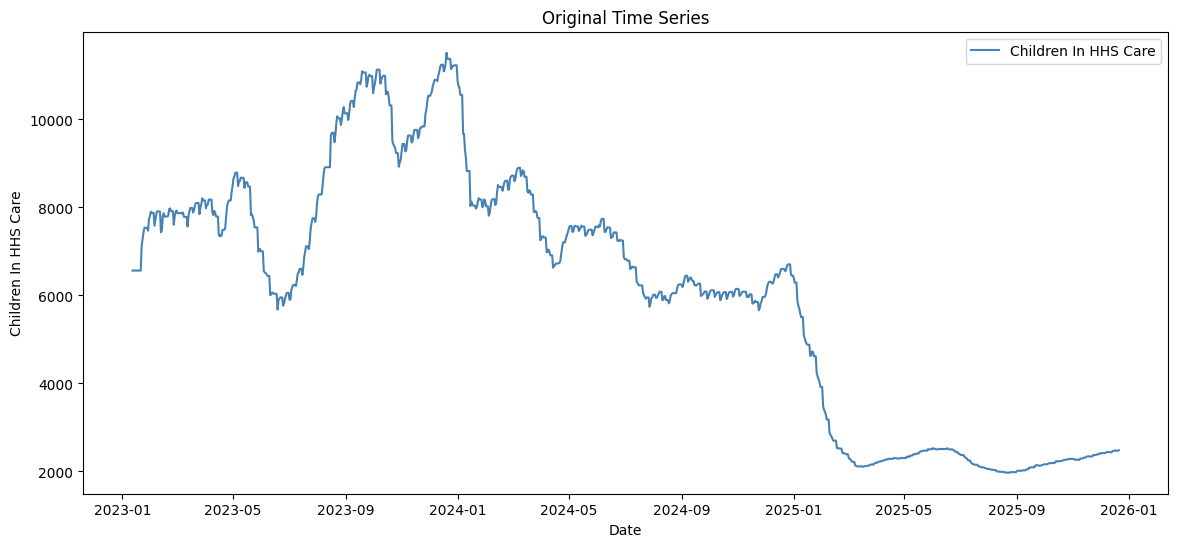

In [18]:
plt.figure(figsize=(14,6))
plt.plot(data.index,
         data['Children in HHS Care'],
         label='Children In HHS Care',
         color='steelblue')

plt.title("Original Time Series")
plt.xlabel("Date")
plt.ylabel("Children In HHS Care")
plt.legend()
plt.show()

 Decompose series into trend, seasonality, and residuals

DECOMPOSE TIME SERIES

In [19]:
data['Children in HHS Care'] = data['Children in HHS Care'].interpolate()
data['Children discharged from HHS Care'] = data['Children discharged from HHS Care'].interpolate()


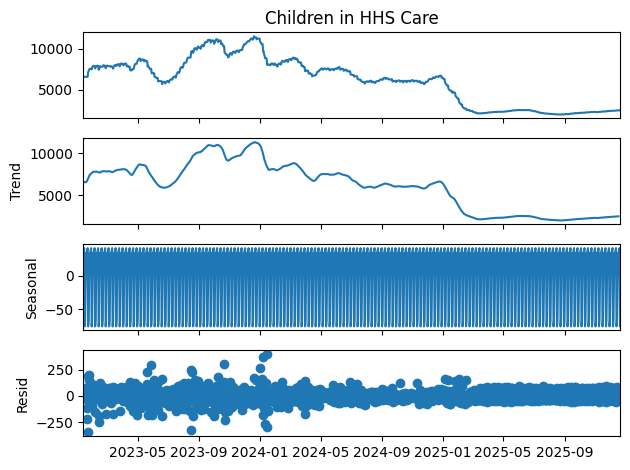

In [20]:
decomposition =  seasonal_decompose(data['Children in HHS Care'], model='additive', period=7)
decomposition.plot()
plt.show()

EXTRACT COMPONENTS

In [21]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


PLOT DECOMPOSITION

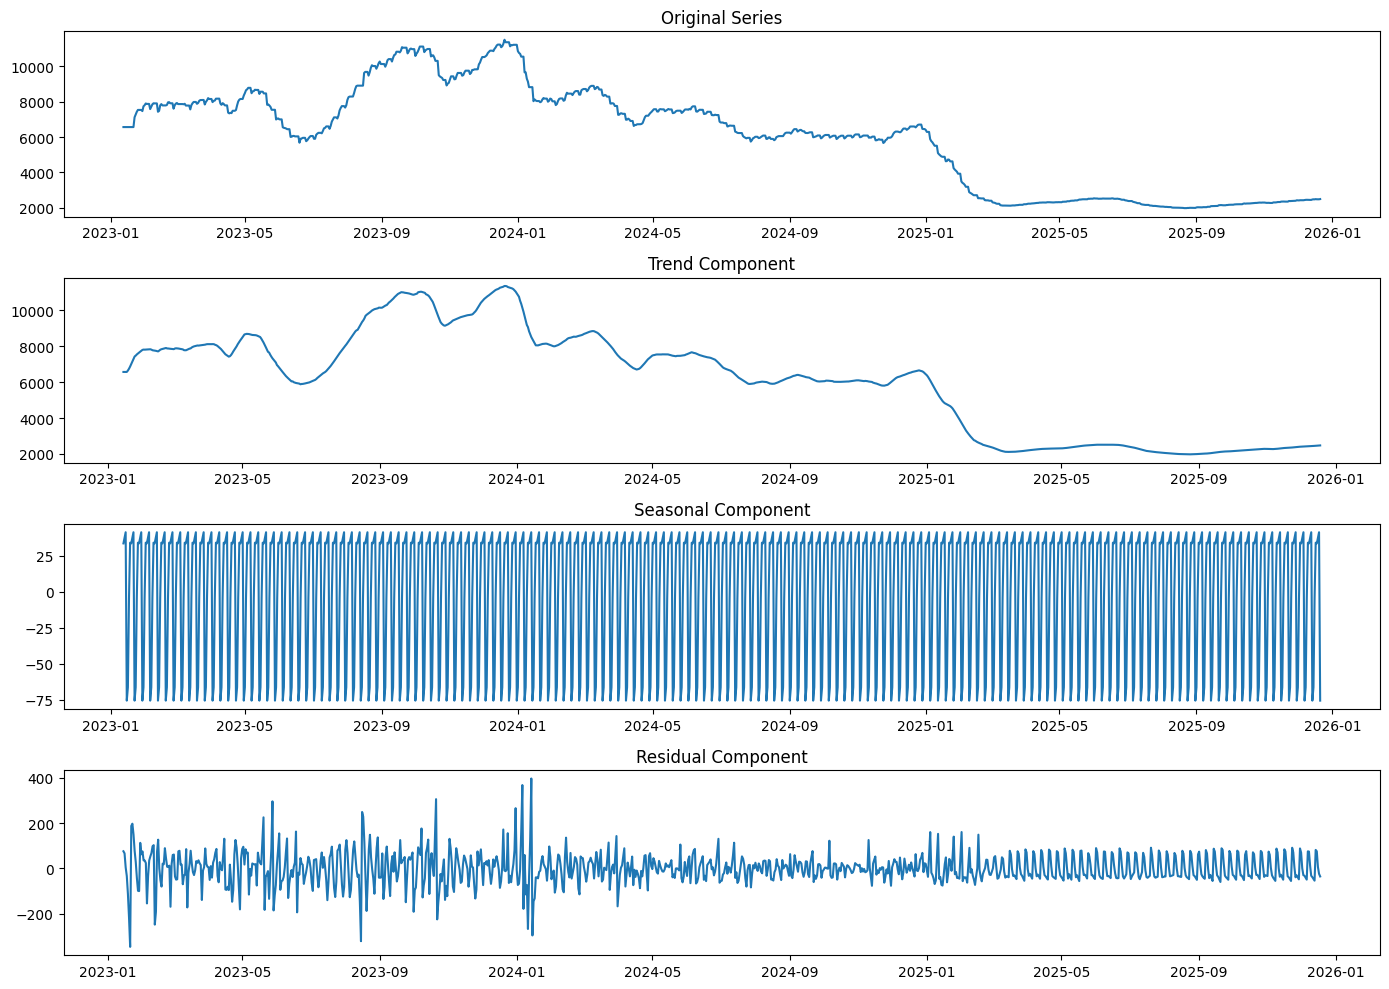

In [22]:
plt.figure(figsize=(14,10))

# Original Series
plt.subplot(4,1,1)
plt.plot(data['Children in HHS Care'])
plt.title("Original Series")

# Trend
plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend Component")

# Seasonal
plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal Component")

# Residual
plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual Component")

plt.tight_layout()

plt.show()


**Feature Engineering**

In [23]:
df = data.copy()

**Lag Features(t-1, t-7, t-14 values)**

In [24]:
df["lag1"] = df["Children in HHS Care"].shift(1)
df["lag7"] = df["Children in HHS Care"].shift(7)
df["lag14"] = df["Children in HHS Care"].shift(14)

**Rolling averages (7-day and 14-day rolling mean and variance)**

In [25]:
df["roll_mean7"] = df["Children in HHS Care"].rolling(window=7).mean()
df["roll_var7"] = df["Children in HHS Care"].rolling(window=7).var()
df["roll_mean14"] = df["Children in HHS Care"].rolling(window=14).mean()
df["roll_var14"] = df["Children in HHS Care"].rolling(window=14).var()

**Flow-Based Signals: Transfers − Discharges (net pressure indicator)**

In [26]:
df["Children transferred out of CBP custody"] = pd.to_numeric(df["Children transferred out of CBP custody"], errors='coerce')
df["Children discharged from HHS Care"] = pd.to_numeric(df["Children discharged from HHS Care"], errors='coerce')
df["net_pressure"] = df["Children transferred out of CBP custody"] - df["Children discharged from HHS Care"]

**Calendar Effects**

In [27]:
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

**# Optional holiday proxy**

In [28]:
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())
df['is_holiday'] = df.index.isin(holidays).astype(int)
df = df.dropna()

**Train-Test Split (time-based)**

In [29]:
X = data.drop("Children discharged from HHS Care", axis=1)   # replace target_column with your actual target
y = data["Children discharged from HHS Care"]


In [30]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train.drop(columns=["Children in HHS Care"])
y_train = train["Children in HHS Care"]
X_test = test.drop(columns=["Children in HHS Care"])
y_test = test["Children in HHS Care"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Forecasting Models**

** Baseline Models**

In [31]:
y_pred_naive = y_test.shift(1).fillna(method='bfill')
y_pred_ma = y_test.rolling(7).mean().fillna(method='bfill')

/tmp/ipykernel_724/3349074463.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_naive = y_test.shift(1).fillna(method='bfill')
/tmp/ipykernel_724/3349074463.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_ma = y_test.rolling(7).mean().fillna(method='bfill')


**Statistical Models**

In [32]:
arima_model = ARIMA(train['Children in HHS Care'], order=(2,1,2))
arima_fit = arima_model.fit()
y_pred_arima = arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


**Machine Learning Models**

In [33]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [34]:
print(X_train.isnull().sum())   # if X_train is a DataFrame
print(np.isnan(X_train).any())
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]  # keep labels aligned
X_test = X_test.dropna()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
dtype: int64
Children apprehended and placed in CBP custody*    False
Children in CBP custody                            False
Children transferred out of CBP custody            False
Children in HHS Care                               False
dtype: bool


In [35]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


**Evaluation Metrics**

In [36]:
results={}

Naive -> MAE: 150.21, RMSE: 186.21, MAPE: 669.32%
Moving Average -> MAE: 99.52, RMSE: 120.33, MAPE: 509.36%
ARIMA -> MAE: 2367.05, RMSE: 2371.02, MAPE: 27346.16%
Random Forest -> MAE: 20.30, RMSE: 35.22, MAPE: nan%
Gradient Boosting -> MAE: 23.93, RMSE: 35.72, MAPE: nan%


/tmp/ipykernel_724/3660510247.py:10: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mask = (~y_true.isna()) & (~pd.Series(y_pred).isna())
/tmp/ipykernel_724/3660510247.py:10: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mask = (~y_true.isna()) & (~pd.Series(y_pred).isna())


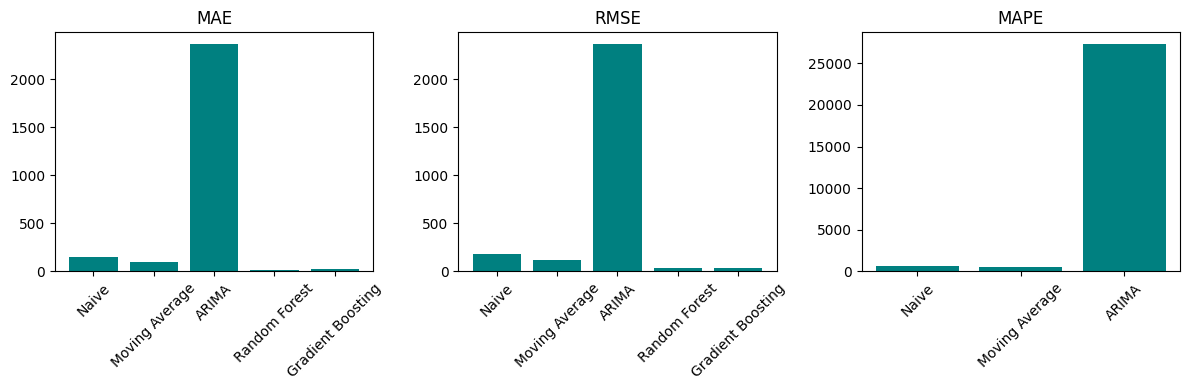

In [37]:
def evaluate(y_true, y_pred, model_name):
  min_len = min(len(y_true), len(y_pred))
  y_true = y_true[:min_len]
  y_pred = y_pred[:min_len]
  y_true = pd.to_numeric(y_true, errors='coerce')
  y_pred = pd.to_numeric(y_pred, errors='coerce')
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
  mask = (~y_true.isna()) & (~pd.Series(y_pred).isna())
  y_true = y_true[mask]
  y_pred = pd.Series(y_pred)[mask]
  nonzero_mask = y_true != 0
  if nonzero_mask.sum() > 0:
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
  else:
    mape = np.nan
  results[model_name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
  print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

evaluate(y_test, y_pred_naive, "Naive")
evaluate(y_test, y_pred_ma, "Moving Average")
evaluate(y_test, y_pred_arima, "ARIMA")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")
metrics = ["MAE", "RMSE", "MAPE"]

plt.figure(figsize=(12,4))
for i, metric in enumerate(metrics):
    plt.subplot(1,3,i+1)
    values = [results[m][metric] for m in results]
    plt.bar(results.keys(), values, color='teal')
    plt.title(metric)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
import joblib
rf.random_state = None
gb.random_state = None
joblib.dump(rf, 'random_forest.pkl')
joblib.dump(gb, 'gradient_boosting.pkl')

['gradient_boosting.pkl']

In [39]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import joblib

rf = joblib.load("random_forest.pkl")
gb = joblib.load("gradient_boosting.pkl")

initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

rf_onnx = convert_sklearn(rf, initial_types=initial_type)
gb_onnx = convert_sklearn(gb, initial_types=initial_type)

with open("random_forest.onnx", "wb") as f:
    f.write(rf_onnx.SerializeToString())
with open("gradient_boosting.onnx", "wb") as f:
    f.write(gb_onnx.SerializeToString())

In [40]:
from google.colab import files
files.download('random_forest.onnx')
files.download('gradient_boosting.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>